## Set-up

In [16]:
# Import core and specialist libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tqdm as notebook_tqdm

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import hdbscan, umap

# Configure plotting styles and disable warnings
# import warnings
# warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


Import & parse geojson dataframe:

In [2]:
#open file
with open("business-licences.geojson") as f:
    #load geojson_data using json parser
    geojson_data = json.load(f)

#print total features count
print("# of features:", len(geojson_data['features']))
#print formatted JSON representation of the first feature
print()
print(json.dumps(geojson_data['features'][3], indent=2))

# of features: 204107

{
  "type": "Feature",
  "geometry": {
    "coordinates": [
      -123.118192793095,
      49.2877342016388
    ],
    "type": "Point"
  },
  "properties": {
    "folderyear": "24",
    "licencersn": "4518848",
    "licencenumber": "24-138567",
    "licencerevisionnumber": "10",
    "businessname": "Baron Global Financial Canada Ltd",
    "businesstradename": null,
    "status": "Issued",
    "issueddate": "2023-12-11T10:12:12-08:00",
    "expireddate": "2024-12-31",
    "businesstype": "Consulting and Management Services",
    "businesssubtype": null,
    "unit": "2250",
    "unittype": "Unit",
    "house": "1055",
    "street": "W HASTINGS ST",
    "city": "Vancouver",
    "province": "BC",
    "country": "CA",
    "postalcode": "V6E 2E9",
    "localarea": "Downtown",
    "numberofemployees": 5.0,
    "feepaid": null,
    "extractdate": "2026-07-01T02:32:17-07:00",
    "geo_point_2d": {
      "lon": -123.118192793095,
      "lat": 49.2877342016388
    }
  }
}


In [3]:
#flatten GeoJSON into a standard 2D pandas DataFrame 
rows = []
for feature in geojson_data["features"]:
    props = feature['properties']
    #if there are no geo coords, default to empty array
    geo = props.get('geo_point_2d') or {}
    #extract
    lat = geo.get('lat')
    lon = geo.get('lon')

    #incase the geo2d doesn't have lat and lon but geom does:
    if lat is None or lon is None:
        geom = feature.get('geometry')
        #if geom is dictionary then extracts coords
        if isinstance(geom, dict):
            coords = geom.get('coordinates')
            # coords is a list/tuple with at least 2 elements
            if isinstance(coords, (list, tuple)) and len(coords) >= 2:
                lon, lat = coords[0], coords[1]  # GeoJSON stores [longitude, latitude]
        
    #append
    rows.append({**props, 'latitude': lat, 'longitude': lon})

df = pd.DataFrame(rows)

# Inspect
print("shape:", df.shape)
df.head()

shape: (204107, 27)


,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,latitude,longitude
0,24,4518841,24-138560,10,Nobl Collective Ltd,NaN,Issued,2023-12-28T13:34:28-08:00,2024-12-31,Consulting and Management Services,...,CA,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,None,NaN,NaN
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20T13:40:18-08:00,2024-12-31,Business Support Services,...,CA,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,None,NaN,NaN
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21T14:30:07-08:00,2024-12-31,Consulting and Management Services,...,CA,NaN,Downtown,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,None,NaN,NaN
3,24,4518848,24-138567,10,Baron Global Financial Canada Ltd,NaN,Issued,2023-12-11T10:12:12-08:00,2024-12-31,Consulting and Management Services,...,CA,V6E 2E9,Downtown,5.0,NaN,2026-07-01T02:32:17-07:00,NaN,"{'lon': -123.118192793095, 'lat': 49.287734201...",49.287734,-123.118193
4,24,4518856,24-138576,10,Jennifer D S Dezell (Jennifer Dezell),Dentons Canada LLP,Issued,2023-12-08T16:34:17-08:00,2024-12-31,Legal Services,...,CA,V6C 3R8,Downtown,217.0,NaN,2026-07-01T02:32:17-07:00,NaN,"{'lon': -123.113252488858, 'lat': 49.286652613...",49.286653,-123.113252


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204107 entries, 0 to 204106
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   folderyear             204107 non-null  str    
 1   licencersn             204107 non-null  str    
 2   licencenumber          204107 non-null  str    
 3   licencerevisionnumber  204107 non-null  str    
 4   businessname           190635 non-null  str    
 5   businesstradename      77307 non-null   str    
 6   status                 204107 non-null  str    
 7   issueddate             175296 non-null  str    
 8   expireddate            175320 non-null  str    
 9   businesstype           204107 non-null  str    
 10  businesssubtype        21518 non-null   str    
 11  unit                   48914 non-null   str    
 12  unittype               48650 non-null   str    
 13  house                  109704 non-null  str    
 14  street                 109721 non-null  str    

In [5]:
df.describe()

,numberofemployees,feepaid,geom,latitude,longitude
count,204107.000000,128649.000000,0.0,102566.000000,102566.000000
mean,10.027549,517.069219,NaN,49.265861,-123.112127
std,72.798081,1110.394696,NaN,0.021525,0.031856
min,0.000000,2.000000,NaN,49.200531,-123.219197
25%,0.000000,207.000000,NaN,49.260353,-123.127872
50%,1.000000,277.000000,NaN,49.269686,-123.117238
75%,4.000000,405.000000,NaN,49.282621,-123.098740
max,5876.000000,63722.000000,NaN,49.295631,-123.024016


## A1 — Data acquisition and cleaning

### Data-cleaning

1. **Records with No Geographic Coordinates: `geom` `geo_point_2d` `geometry` & `latitude` `longitude`**

We can't apply K-Means or DBScan on locations without coordinations, therefore these should be removed

In [6]:
# drop rows with missing latitude & longitude 
df_spatial = df.dropna(subset=['latitude', 'longitude']).copy()
print("length before dropping null lat/lon:", len(df['longitude']))
print("length after:", len(df_spatial['longitude']))

length before dropping null lat/lon: 204107
length after: 102566


Drop redundant geometry columns

In [7]:
df_spatial = df_spatial.drop(columns=['geom', 'geo_point_2d', 'geometry'], errors='ignore')

2. **Combine businesstype and businesssubtype into a single, more fine-grained industry label where a subtype exists**

First I'll standardize the typecase for all the entries + clean up bad entries

Then I'll combine the subtype with a '-' if it exists. Otherwise, do nothing.

In [8]:
unique_categories = df_spatial['businesstype'].unique()
print(unique_categories)

<ArrowStringArray>
[                                 'Consulting and Management Services',
                                                      'Legal Services',
                                                     'Mining Services',
                                                    'Tourism Services',
                              'Architectural and Engineering Services',
                                           'Business Support Services',
                                                'Real Estate Services',
                                                  'Financial Services',
                                                     'Design Services',
                                                  'General Contractor',
                                                  'Brokerage Services',
                                                       'Street Vendor',
                                                  'Insurance Services',
                                             

In [9]:
#strip strings & make lowercase
df_spatial['businesstype'] = df_spatial['businesstype'].astype(str).str.strip()
df_spatial['businesssubtype'] = df_spatial['businesssubtype'].astype(str).str.strip()

#make nulls valid pandas type
df_spatial['businesssubtype'] = df_spatial['businesssubtype'].replace(['None', 'nan', '', 'null'], np.nan)
df_spatial['businesstype'] = df_spatial['businesstype'].replace(['None', 'nan', '', 'null'], np.nan)

# if businesssubtype is not NA then combine it with business type otherwise default to business type
df_spatial['business_category'] = np.where(
    df_spatial['businesssubtype'].notna(),
    df_spatial['businesstype'] + " - " + df_spatial['businesssubtype'],
    df_spatial['businesstype']
)

#drop redundant category
df_spatial = df_spatial.drop(columns=['businesstype', 'businesssubtype'], errors='ignore')

#if any categories still empty, fill with 'unspecified'
df_spatial['business_category'] = df_spatial['business_category'].fillna('Unspecified')

In [10]:
print("columns:", df_spatial.columns.tolist())

columns: ['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber', 'businessname', 'businesstradename', 'status', 'issueddate', 'expireddate', 'unit', 'unittype', 'house', 'street', 'city', 'province', 'country', 'postalcode', 'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'latitude', 'longitude', 'business_category']


3. **Group by `business_category` and then input missing `numberofemployees` with that domain-specific median.**

This prevents heavy right-skewing since the businesses themselves pull the mean upwards when they record their number of employees. The median ensures missing values are realistically standardized to be resilient to the outliers



In [11]:
#force typing to number
df_spatial['numberofemployees'] = pd.to_numeric(df_spatial['numberofemployees'], errors='coerce')

# group median imputation with fallback to global median
df_spatial['numberofemployees'] = df_spatial.groupby('business_category')['numberofemployees'].transform(
    lambda x: x.fillna(x.median())
)

# scale business_categories with 0 employees with 1.0
df_spatial['numberofemployees'] = df_spatial['numberofemployees'].fillna(df_spatial['numberofemployees'].median()).fillna(1.0)

5. **Do the same to the `feepaid`**

In [12]:
fee_median = df_spatial['feepaid'].median()
if pd.isna(fee_median): fee_median = 0.0

df_spatial['feepaid'] = df_spatial.groupby('business_category')['feepaid'].transform(
    lambda x: x.fillna(x.median())
).fillna(fee_median).fillna(0.0)

4.  **Filter to a sensible subset (e.g., status == "Issued") and justify**

Since `Gone Out of Business`, `Inactive`, & `Cancelled` can be considered noise and phantom clusters, we filter by issued so every datapoint is valid.

`pending` is removed because the application process was never finalized and thus usually have `feepaid` as 0. Removing them prevents distorting feature scaling.

In [13]:
#number of each status
print(df_spatial['status'].value_counts(dropna=False))

# filter for active/valid licenses
df_active = df_spatial[df_spatial['status'] == 'Issued'].copy()

print(f"\nBefore: {len(df_spatial)} records")
print(f"\nAfter (status == 'Issued'): {len(df_active)} records")
print(f"\nretained: {(len(df_active) / len(df_spatial)) * 100:.1f}%")

status
Issued                  85872
Pending                  5909
Gone Out of Business     4800
Inactive                 4184
Cancelled                1801
Name: count, dtype: int64

Before: 102566 records

After (status == 'Issued'): 85872 records

retained: 83.7%


Save dataset so I don't need to load geojson everytime.

In [15]:
df_active.to_csv("vancouver_business_licences_clean.csv", index=False)
df_active.to_parquet("vancouver_business_parquet.parquet", index=False)

print("Saved clean dataset")

Saved clean dataset


## A2 — Location-only clustering: K-means vs. DBSCAN

In [18]:
df_active = pd.read_csv("vancouver_business_licences_clean.csv")

### Scaling

In [19]:
geo_coords = df_active[['latitude', 'longitude']]
scaler = StandardScaler()
X_geo_scaled = scaler.fit_transform(df_active[['latitude', 'longitude']])

### K-Means

Elbow method & visualize elbow curve plot to choose K.

In [20]:
inertias = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_geo_scaled)
    inertias.append(kmeans.inertia_)

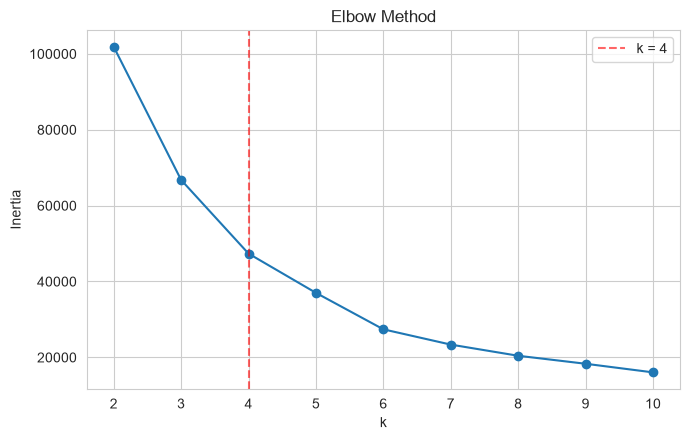

In [21]:
plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), inertias, marker='o') 
plt.xlabel('k') 
plt.ylabel('Inertia') 
plt.title('Elbow Method') 
plt.axvline(4, color='red', linestyle='--', alpha=0.6, label=f'k = 4') 
plt.legend()
plt.tight_layout()
plt.show()

I've chosen K = 4 because inertia decreases sharply from 3 -> 4. Then the drop plateaus and stops oversegmenting.

Fit Final K-Means Model

In [22]:
K = 4
kmeans_geo = KMeans(n_clusters=K, random_state=42, n_init=10)
df_active['kmeans_geo_cluster'] = kmeans_geo.fit_predict(X_geo_scaled)

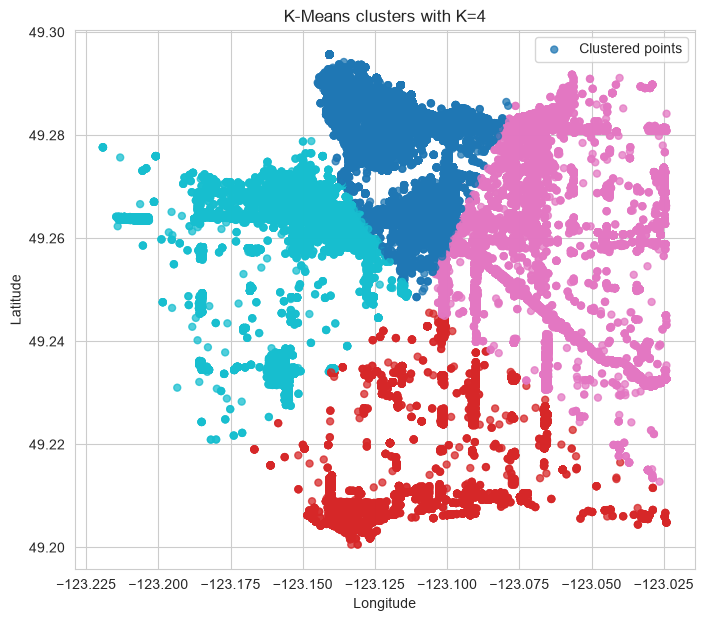

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    df_active["longitude"], 
    df_active["latitude"], 
    c=df_active["kmeans_geo_cluster"], 
    cmap="tab10", 
    s=25, 
    alpha=0.75, 
    label="Clustered points"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"K-Means clusters with K={K}")
ax.legend()
plt.show()

### DBSCAN

Fit DBSCAN Model

In [24]:
df_active.info()

<class 'pandas.DataFrame'>
RangeIndex: 85872 entries, 0 to 85871
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   folderyear             85872 non-null  int64  
 1   licencersn             85872 non-null  int64  
 2   licencenumber          85872 non-null  str    
 3   licencerevisionnumber  85872 non-null  int64  
 4   businessname           85869 non-null  str    
 5   businesstradename      42921 non-null  str    
 6   status                 85872 non-null  str    
 7   issueddate             85726 non-null  str    
 8   expireddate            85725 non-null  str    
 9   unit                   37237 non-null  str    
 10  unittype               37053 non-null  str    
 11  house                  85872 non-null  int64  
 12  street                 85872 non-null  str    
 13  city                   85872 non-null  str    
 14  province               85872 non-null  str    
 15  country      

In [25]:
dbscan = DBSCAN(eps=0.06, min_samples=30)
df_active['dbscan_geo_cluster'] = dbscan.fit_predict(X_geo_scaled)

n_clusters_dbscan = len(set(df_active['dbscan_geo_cluster'])) - (1 if -1 in df_active["dbscan_geo_cluster"].values else 0)
n_noise_dbscan = (df_active["dbscan_geo_cluster"] == -1).sum()
# print number of clusters found and number of noise points flagged
print(f"number of clusters: {n_clusters_dbscan}\nnumber of noise points: {n_noise_dbscan}")

number of clusters: 79
number of noise points: 2270


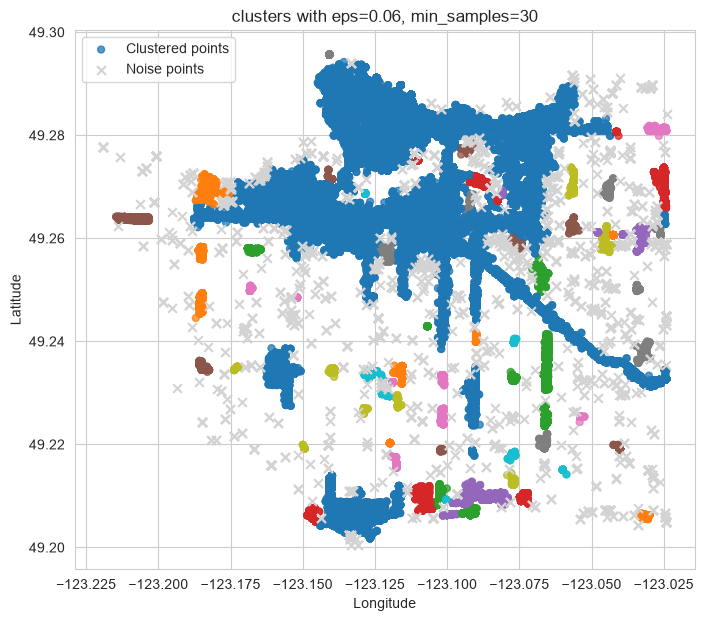

In [26]:
# create scatter plot of Longitude vs Latitude
fig, ax = plt.subplots(figsize=(8,7))

# plot clustered points colored by DBSCAN_Cluster
noise_mask = df_active['dbscan_geo_cluster'] == -1
ax.scatter(df_active.loc[~noise_mask, "longitude"], df_active.loc[~noise_mask, "latitude"],
    c = df_active.loc[~noise_mask, "dbscan_geo_cluster"], cmap="tab10", s=25, alpha=0.75, label="Clustered points")
# plot noise points (cluster = -1) as light gray 'x' markers and show plot
ax.scatter(df_active.loc[noise_mask, "longitude"], df_active.loc[noise_mask, "latitude"],
           c = "lightgray", marker="x", s=40, label="Noise points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("clusters with eps=0.06, min_samples=30")
ax.legend()
plt.show()



### Points colored by cluster assignment, one for each method

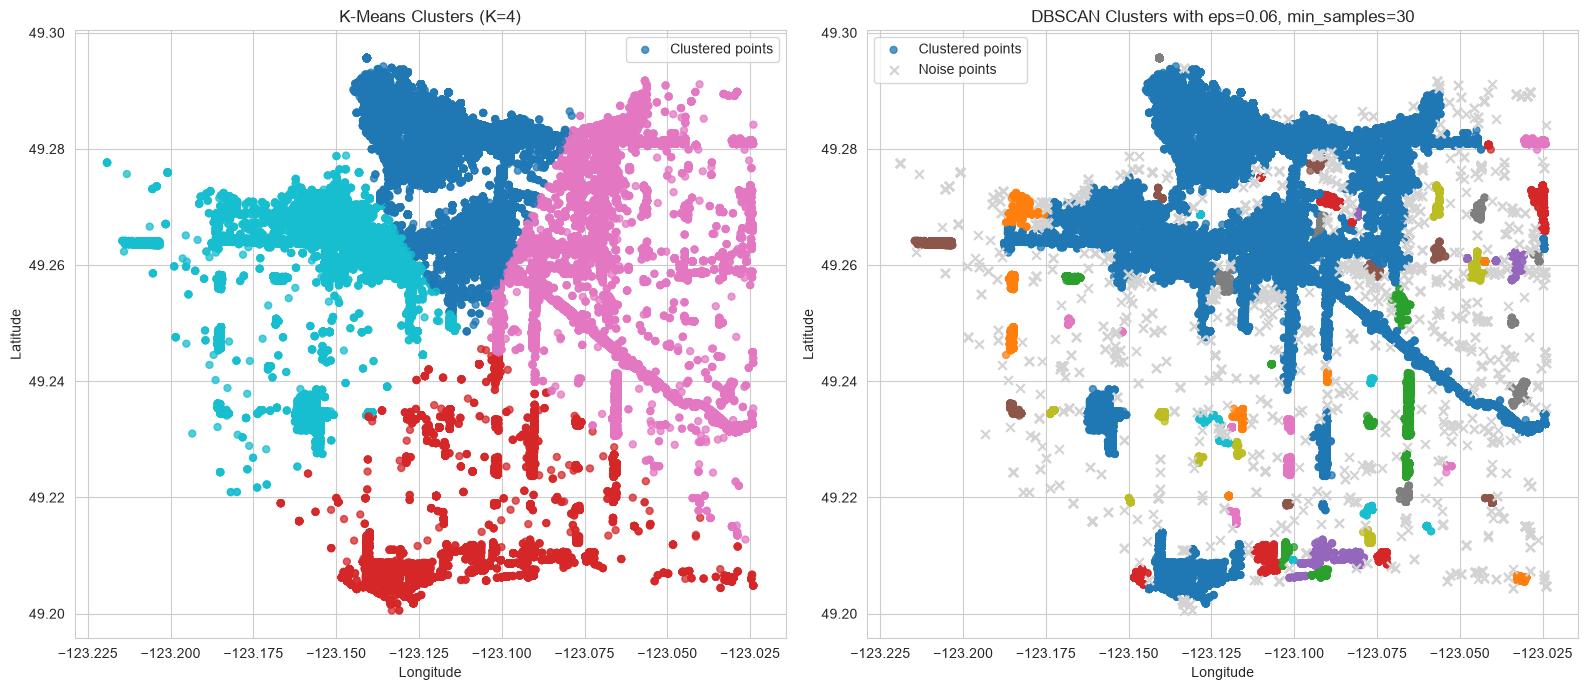

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. K-Means Plot
axes[0].scatter(
    df_active["longitude"], 
    df_active["latitude"], 
    c=df_active["kmeans_geo_cluster"], 
    cmap="tab10", 
    s=25, 
    alpha=0.75, 
    label="Clustered points"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"K-Means Clusters (K={K})")
axes[0].legend()

# 2. DBSCAN Plot
noise_mask = df_active['dbscan_geo_cluster'] == -1

# clustered points
axes[1].scatter(
    df_active.loc[~noise_mask, "longitude"], 
    df_active.loc[~noise_mask, "latitude"], 
    c=df_active.loc[~noise_mask, "dbscan_geo_cluster"], 
    cmap="tab10", 
    s=25, 
    alpha=0.75, 
    label="Clustered points"
)

# noise
axes[1].scatter(
    df_active.loc[noise_mask, "longitude"], 
    df_active.loc[noise_mask, "latitude"], 
    c="lightgray", 
    marker="x", 
    s=40, 
    label="Noise points"
)

axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("DBSCAN Clusters with eps=0.06, min_samples=30")
axes[1].legend()

plt.tight_layout()
plt.show()

### Questions

1. **How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?**

For K-Means = 4, the city is divided into four regions around its centre. The dark blue cluster looks like the Grandville and Downtown area, while the pink one looks like Kingsway or East Van.

2. **How do the DBSCAN clusters compare? Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.**

While K-Means forces 4 equal parts of the city to be segmented, DBSCAN gives us a more accurate idea of the actual density of commercial Vancouver businesses without assuming anything.

They agree that Downtown Vancouver is the primary most dense business hub of all the other groups. 

The main disagreement is on what shapes separate groups make up. K-Means takes into account all dots but DBSCAN prioritizes finding clusters while disregarding other points as noise.

##  A3 — Feature-based clustering: Size, Industry, Lifecycle 

In [29]:
df = df_active.copy()

### Feature engineering

Size — number of employees, fee paid

In [33]:
df['log_employees'] = np.log1p(df['numberofemployees'].clip(lower=0))
df['log_feepaid'] = np.log1p(df['feepaid'].clip(lower=0))

Lifecycle — licence duration (expireddate − issueddate), month issued (cyclically encoded), licence revision number

In [32]:
# turn into parsed dates
df['issueddate'] = pd.to_datetime(df['issueddate'], format='mixed', utc=True, errors='coerce')
df['expireddate'] = pd.to_datetime(df['expireddate'], format='mixed', utc=True, errors='coerce')

# expireddate - issueddate in days
df['licence_duration'] = (df['expireddate'] - df['issueddate']).dt.days
df['licence_duration'] = df['licence_duration'].fillna(df['licence_duration'].median())

# cyclically encoded (sin/cos representation of months 1-12 )
df['issue_month'] = df['issueddate'].dt.month.fillna(1)
df['issue_month_sin'] = np.sin(2 * np.pi * df['issue_month'] / 12.0)
df['issue_month_cos'] = np.cos(2 * np.pi * df['issue_month'] / 12.0)

# liscence revision number
df['licencerevisionnumber'] = pd.to_numeric(df.get('licencerevisionnumber', 1), errors='coerce').fillna(0)

Industry - consolidated business type (or type+subtype) categories, encoded

In [35]:
top_categories = df['business_category'].value_counts().head(15).index
df['category_grouped'] = df['business_category'].apply(lambda x: x if x in top_categories else 'Other')

top_categories

Index(['Health Care Professionals and Services', 'Long-term Rental',
       'Retail Dealer', 'Legal Services',
       'Restaurant - Class 1 with liquor service', 'Business Support Services',
       'Financial Services', 'Consulting and Management Services',
       'Limited Service Food Establishment - Without Liquor',
       'Real Estate Services', 'Retail Dealer - Food', 'General Contractor',
       'Information Communication Technology', 'Association or Society',
       'Restaurant - Class 1 no liquor service'],
      dtype='str', name='business_category')

Column concating and hot-encoding, helped by Gemini with prompt: `Help me debug this function where I can scale number columns and hot-encode categories columns.` 

In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

num_cols = ['log_employees', 'log_feepaid', 'licence_duration', 
            'issue_month_sin', 'issue_month_cos', 'licencerevisionnumber']
cat_cols = ['category_grouped']

#BEGIN
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

X_features = preprocessor.fit_transform(df)
print(f"Engineered Feature Matrix Shape: {X_features.shape}")
#END

Engineered Feature Matrix Shape: (85872, 21)


### Fit K-Means, Apply PCA, and Plot Clusters

Fit K-Means on scaled features

In [37]:
K = 4
kmeans_feat = KMeans(n_clusters=K, random_state=42, n_init=10)
df['feature_cluster'] = kmeans_feat.fit_predict(X_features)

Apply PCA to project to 2D 

In [38]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_features)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

var_ratio = pca.explained_variance_ratio_

Visualize the clusters

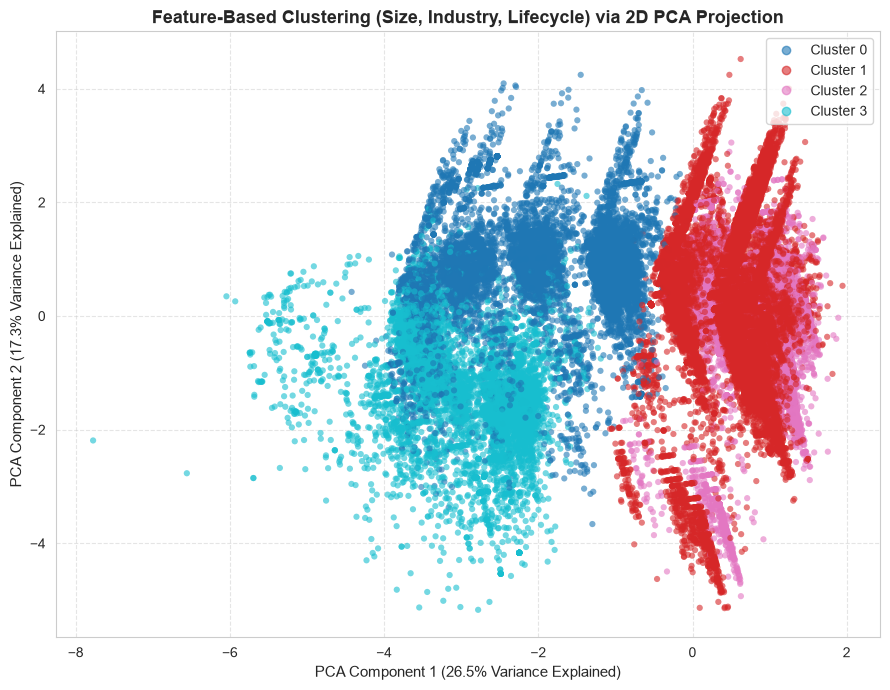

In [40]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    df['pca1'], 
    df['pca2'], 
    c=df['feature_cluster'], 
    cmap='tab10', 
    s=20, 
    alpha=0.6,
    edgecolor='none'
)

ax.set_xlabel(f"PCA Component 1 ({var_ratio[0]*100:.1f}% Variance Explained)", fontsize=11)
ax.set_ylabel(f"PCA Component 2 ({var_ratio[1]*100:.1f}% Variance Explained)", fontsize=11)
ax.set_title("Feature-Based Clustering (Size, Industry, Lifecycle) via 2D PCA Projection", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

# Add legend
legend_labels = [f"Cluster {i}" for i in range(K)]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, loc="upper right")

plt.tight_layout()
plt.show()

### Markdown
1. **What do the resulting clusters seem to represent? Does this differ from the purely geographic clustering in A2?**

Cluster 3 (Cyan) - Negative PCA values, where PCA < -3.0
- Large retail stores with lots of employees, hotels, and other types of high-fee chains

Cluster 0 (Blue) - Central, -3 < PCA < -0.5
- Mid-scale businesses and standard stores. Restaurants with standard employee numbers and fees.

Cluster 1 (Red) - Positive PCA values, 0 < PCA < 1.0
- Small business, single person services & small trades businesses

Cluster 2 (Pink) - High Positive PCA values, > 1.0
- Extremely specific one-hot encoded stores with unpredictable license insurance patterning 

This feature-based clustering differs from the geographic clustering (K-means, DBscan in A2) because its on operational scale and power instead of physical location. So even if two banks aren't anywhere near each other but have the same value of features, they're clustered together.

PCA also tells us the variances in features. Where X = Business scale/size, Y = Lifecycle
